# RL2

This notebook trains a DQN policy and visualizes average reward, action distribution, policy comparison, and state statistics. No shell commands are used.

## 1) Setup

In [12]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

from coup.research.bc import benchmark_policy_vs_random, train_behavior_clone
from coup.research.markov import build_transition_dataset_from_sim_dir, write_transition_csv
from coup.research.rl_train import train_dqn_policy
from coup.sim.sim import simulate_games

ROOT = Path.cwd()
if not (ROOT / 'coup').exists():
    fallback = Path('/Users/crishuynh/Documents/SoftwareProject/coup_detection')
    if (fallback / 'coup').exists():
        ROOT = fallback
os.chdir(ROOT)
print('Repository root:', ROOT)

SIM_DIR = ROOT / 'data' / 'sim_rl_fit'
RESEARCH_DIR = ROOT / 'data' / 'research'
MARKOV_CSV = RESEARCH_DIR / 'markov_transitions_rl_fit.csv'
BC_DIR = RESEARCH_DIR / 'bc_rl_fit'
DQN_DIR = RESEARCH_DIR / 'dqn_rl_fit'

SIM_DIR.mkdir(parents=True, exist_ok=True)
RESEARCH_DIR.mkdir(parents=True, exist_ok=True)


Repository root: /Users/crishuynh/Documents/SoftwareProject/coup_detection


## 2) Config

In [ ]:
CONFIG = {
    'players': 4,
    'games': 80,
    'seed': 321,
    'max_turns': 220,
    'dqn_episodes': 100,
}
CONFIG


{'players': 4, 'games': 80, 'seed': 321, 'max_turns': 220, 'dqn_episodes': 150}

## 3) Build transitions (simulate if needed)

In [14]:
if not MARKOV_CSV.exists():
    results = simulate_games(
        CONFIG['games'],
        players=CONFIG['players'],
        seed=CONFIG['seed'],
        max_turns=CONFIG['max_turns'],
    )
    for idx, result in enumerate(results, start=1):
        (SIM_DIR / f'game_{idx}.json').write_text(json.dumps(result.events, indent=2))

    transitions = build_transition_dataset_from_sim_dir(SIM_DIR)
    write_transition_csv(transitions, MARKOV_CSV)

print('Transitions CSV:', MARKOV_CSV)
print('Exists:', MARKOV_CSV.exists())


Transitions CSV: /Users/crishuynh/Documents/SoftwareProject/coup_detection/data/research/markov_transitions_rl_fit.csv
Exists: True


## 4) Train BC baseline for comparison

In [15]:
BC_DIR.mkdir(parents=True, exist_ok=True)
bc_metrics = train_behavior_clone(MARKOV_CSV, BC_DIR, seed=42)
bc_benchmark = benchmark_policy_vs_random(MARKOV_CSV, BC_DIR, seed=42)
print('BC metrics:', bc_metrics)
print('BC benchmark keys:', list(bc_benchmark.keys()))


BC metrics: {'accuracy': 0.4726775956284153, 'f1_macro': 0.3531553817268103}
BC benchmark keys: ['behavior_cloning', 'random_policy']


## 5) Train DQN (fit) and save artifacts

In [28]:
DQN_DIR.mkdir(parents=True, exist_ok=True)
summary = train_dqn_policy(
    transitions_csv=MARKOV_CSV,
    out_dir=DQN_DIR,
    episodes=CONFIG['dqn_episodes'],
    seed=42,
    compare_bc_dir=BC_DIR,
)
summary


{'train_metrics': {'episodes': 150,
  'avg_episode_reward': 4.799333333333332,
  'avg_episode_steps': 18.426666666666666,
  'final_epsilon': 0.47147873742168567},
 'benchmark': {'dqn_policy': {'avg_reward_per_episode': 8.180000000000009,
   'avg_reward_per_step': 0.4476060191518472,
   'action_match_rate': 0.35772913816689467},
  'random_policy': {'avg_reward_per_episode': 4.392500000000004,
   'avg_reward_per_step': 0.24035567715458298,
   'action_match_rate': 0.15047879616963064},
  'behavior_cloning': {'action_match_rate': 0.5068399452804377,
   'avg_reward_per_step': 0.5967168262653899,
   'avg_reward_per_episode': 0.5967168262653899}}}

## 6) Plot average reward over episodes

,episode,reward,steps,epsilon,avg_reward_so_far,rolling_reward_10
4995,4996,17.8,18,0.05,13.407166,14.10
4996,4997,7.6,13,0.05,13.406004,13.47
4997,4998,17.9,16,0.05,13.406903,14.08
4998,4999,11.9,13,0.05,13.406601,13.23
4999,5000,19.0,23,0.05,13.407720,13.42


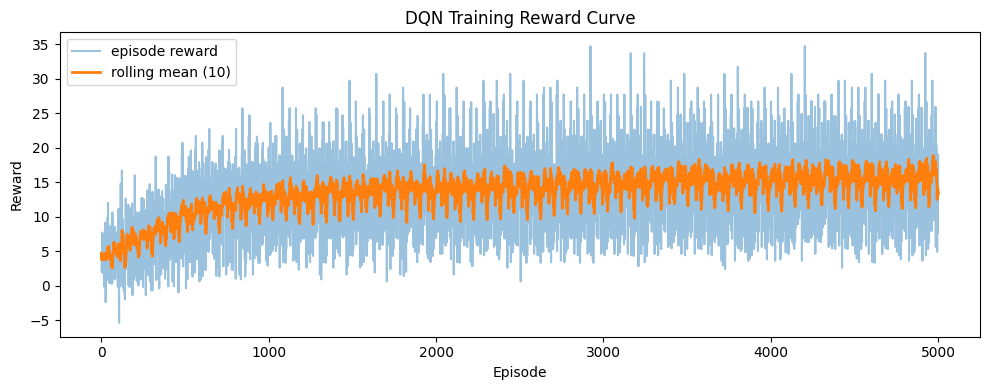

In [17]:
history_df = pd.read_csv(DQN_DIR / 'train_episode_history.csv')
history_df['rolling_reward_10'] = history_df['reward'].rolling(window=10, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_df['episode'], history_df['reward'], label='episode reward', alpha=0.45)
ax.plot(history_df['episode'], history_df['rolling_reward_10'], label='rolling mean (10)', linewidth=2)
ax.set_title('DQN Training Reward Curve')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.legend()
plt.tight_layout()
history_df.tail()


## 7) Plot action distribution during training

,action,count
1,Foreign Aid,23449
3,Steal,19801
2,Tax,17086
0,Income,13352
5,Coup,7000
4,Assassinate,6693
6,Exchange,4015


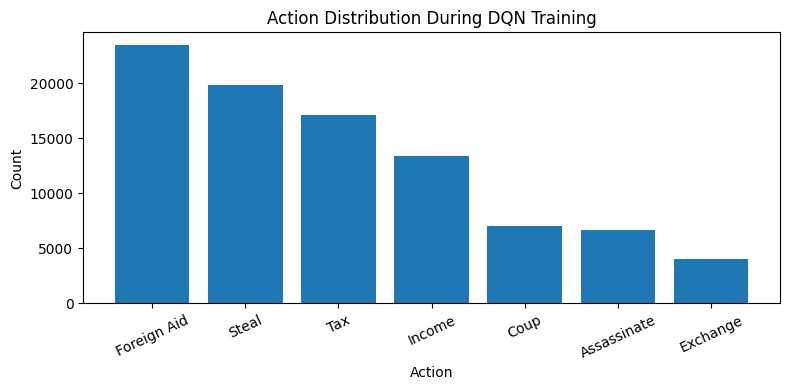

In [18]:
action_counts = json.loads((DQN_DIR / 'train_action_counts.json').read_text())
action_df = pd.DataFrame([{'action': key, 'count': int(value)} for key, value in action_counts.items()])
action_df = action_df.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(action_df['action'], action_df['count'])
ax.set_title('Action Distribution During DQN Training')
ax.set_xlabel('Action')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
action_df


## 8) Plot policy comparison (DQN vs Random vs BC)

,policy,avg_reward_per_episode,action_match_rate
0,dqn_policy,16.555000,0.816005
1,random_policy,4.392500,0.150479
2,behavior_cloning,0.596717,0.506840


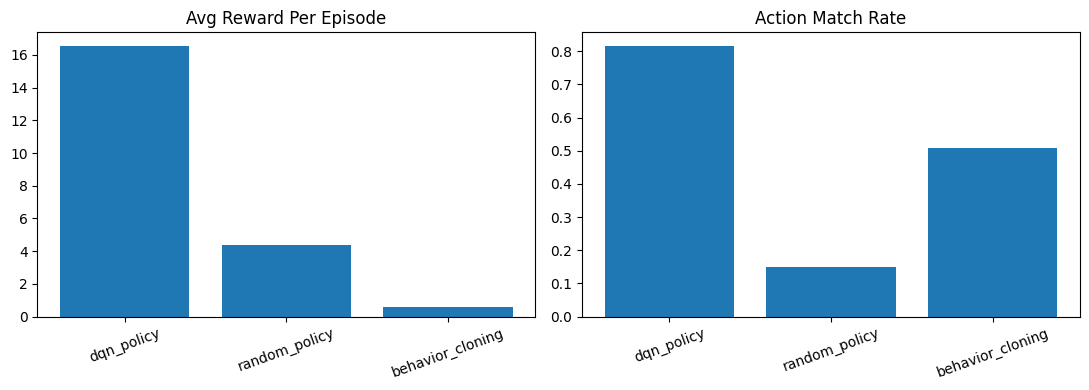

In [19]:
bench = summary['benchmark']
rows = []
for key in ['dqn_policy', 'random_policy', 'behavior_cloning']:
    if key in bench:
        rows.append({
            'policy': key,
            'avg_reward_per_episode': bench[key]['avg_reward_per_episode'],
            'action_match_rate': bench[key]['action_match_rate'],
        })

policy_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(policy_df['policy'], policy_df['avg_reward_per_episode'])
axes[0].set_title('Avg Reward Per Episode')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(policy_df['policy'], policy_df['action_match_rate'])
axes[1].set_title('Action Match Rate')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
policy_df


## 9) Plot state summary from training

State observations: 91396


,state_index,state_mean,state_std
0,0,0.896538,0.304561
1,1,0.144461,0.216099
2,2,0.127630,0.203549
3,3,0.263516,0.340978
4,4,0.120918,0.189642


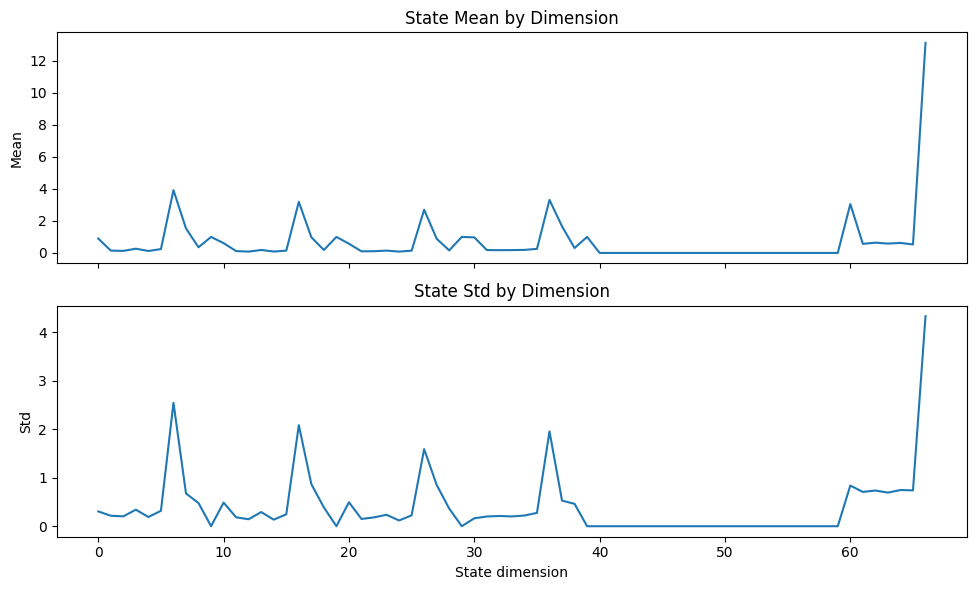

In [20]:
state_summary = json.loads((DQN_DIR / 'train_state_summary.json').read_text())
state_df = pd.DataFrame({
    'state_index': list(range(len(state_summary['state_mean']))),
    'state_mean': state_summary['state_mean'],
    'state_std': state_summary['state_std'],
})

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(state_df['state_index'], state_df['state_mean'])
axes[0].set_title('State Mean by Dimension')
axes[0].set_ylabel('Mean')
axes[1].plot(state_df['state_index'], state_df['state_std'])
axes[1].set_title('State Std by Dimension')
axes[1].set_xlabel('State dimension')
axes[1].set_ylabel('Std')
plt.tight_layout()
print('State observations:', state_summary['observations'])
state_df.head()


## 10) Inspect policy rollout trace (state/action over time)

Trace action_match_rate: 0.816


,game_id,transition_index,chosen_action,logged_action,reward,state_mean,state_norm
0,game_1,0,Tax,Steal,0.5,0.611940,11.036304
1,game_1,1,Exchange,Exchange,1.0,0.611940,10.972892
2,game_1,2,Foreign Aid,Income,0.1,0.611940,10.976543
3,game_1,3,Foreign Aid,Foreign Aid,1.0,0.641791,11.938229
4,game_1,4,Steal,Steal,1.5,0.641791,11.939245


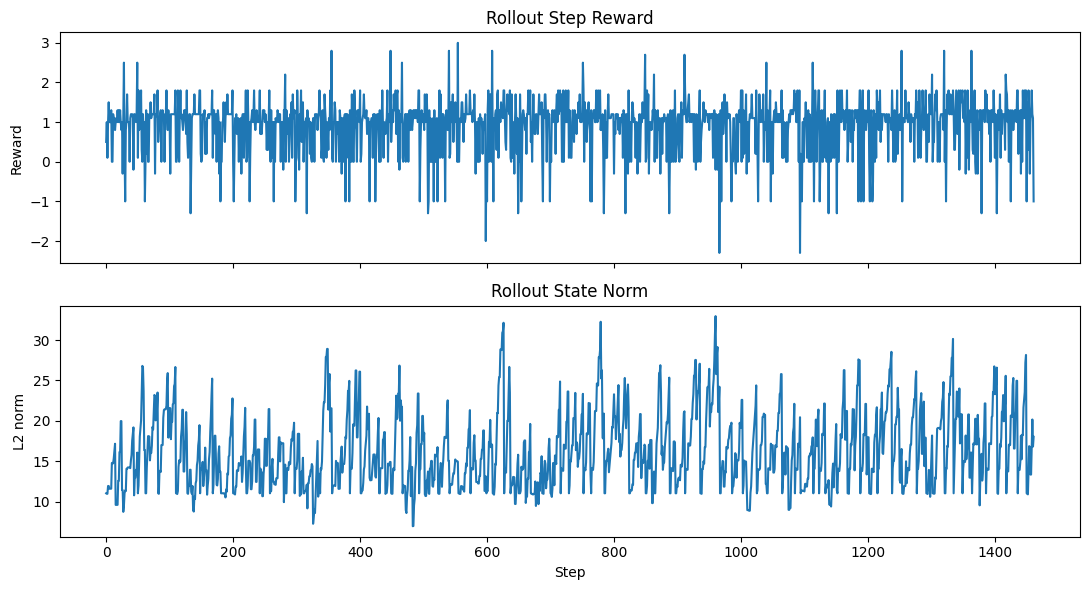

In [21]:
trace_df = pd.read_csv(DQN_DIR / 'dqn_policy_rollout_trace.csv')
trace_df['step_id'] = range(len(trace_df))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(trace_df['step_id'], trace_df['reward'])
axes[0].set_title('Rollout Step Reward')
axes[0].set_ylabel('Reward')
axes[1].plot(trace_df['step_id'], trace_df['state_norm'])
axes[1].set_title('Rollout State Norm')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('L2 norm')
plt.tight_layout()

action_match_rate = float(trace_df['action_match'].mean()) if len(trace_df) else 0.0
print('Trace action_match_rate:', round(action_match_rate, 4))
trace_df[['game_id', 'transition_index', 'chosen_action', 'logged_action', 'reward', 'state_mean', 'state_norm']].head()


## 11) Key artifact files
- `train_episode_history.csv`
- `train_action_counts.json`
- `train_state_summary.json`
- `dqn_policy_rollout_trace.csv`
- `benchmark.json`
- `summary.json`


In [22]:
from pathlib import Path
import shutil
from datetime import datetime

root = Path("/Users/crishuynh/Documents/SoftwareProject/coup_detection/data/research")
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
freeze = root / "frozen_runs" / stamp
freeze.mkdir(parents=True, exist_ok=True)

for name in ["advisor_experiments", "dqn_rl_fit"]:
    src = root / name
    if src.exists():
        shutil.copytree(src, freeze / name)

print("Frozen to:", freeze)


Frozen to: /Users/crishuynh/Documents/SoftwareProject/coup_detection/data/research/frozen_runs/20260412_174110
